# Moving Average Strategy Backtest

This notebook implements a simple moving average crossover trading strategy using historical market data.

The goal is to:
- download financial data
- compute moving averages
- generate trading signals
- backtest the strategy
- compare performance against a buy-and-hold benchmark

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Data Acquisition

We download historical price data for SPY, the ETF that tracks the S&P 500.

In [2]:
dSPY = yf.download("SPY", start="2000-01-01", auto_adjust=False)
dSPY.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY,SPY
Date,,,,,,
2000-01-03,91.617020,145.4375,148.25000,143.875000,148.25000,8164300
2000-01-04,88.034279,139.7500,144.06250,139.640625,143.53125,8089800
2000-01-05,88.191780,140.0000,141.53125,137.250000,139.93750,12177900
2000-01-06,86.774353,137.7500,141.50000,137.750000,139.62500,6227200
2000-01-07,91.813866,145.7500,145.75000,140.062500,140.31250,8066500


In [3]:
if isinstance(dSPY.columns, pd.MultiIndex):
    dSPY.columns = dSPY.columns.get_level_values(0)

dSPY = dSPY.copy()
dSPY.head()

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2000-01-03,91.617020,145.4375,148.25000,143.875000,148.25000,8164300
2000-01-04,88.034279,139.7500,144.06250,139.640625,143.53125,8089800
2000-01-05,88.191780,140.0000,141.53125,137.250000,139.93750,12177900
2000-01-06,86.774353,137.7500,141.50000,137.750000,139.62500,6227200
2000-01-07,91.813866,145.7500,145.75000,140.062500,140.31250,8066500


## 2. Data Exploration

We inspect the structure of the dataset and summary statistics.

In [4]:
print(dSPY.shape)
dSPY.describe()

(6582, 6)


Price,Adj Close,Close,High,Low,Open,Volume
count,6582.000000,6582.000000,6582.000000,6582.000000,6582.000000,6.582000e+03
mean,199.726046,229.745183,231.043778,228.275955,229.722377,1.046720e+08
std,157.588757,149.090380,149.735574,148.287636,149.051515,8.937073e+07
min,49.944572,68.110001,70.000000,67.099998,67.949997,1.436600e+06
25%,84.937407,121.342497,121.989998,120.634998,121.309998,5.084682e+07
50%,119.882607,154.050003,154.674995,153.099998,153.845001,7.792325e+07
75%,263.357010,290.757507,292.022499,289.610001,290.984993,1.311525e+08
max,695.489990,695.489990,697.840027,693.940002,697.049988,8.710263e+08


## 3. Technical Indicators

We compute two moving averages:
- 50-day moving average
- 200-day moving average

These are used to build a simple trend-following strategy.

In [5]:
dSPY["MA50"] = dSPY["Close"].rolling(50).mean()
dSPY["MA200"] = dSPY["Close"].rolling(200).mean()

dSPY[["Close", "MA50", "MA200"]].tail()

Price,Close,MA50,MA200
Date,,,
2026-02-27,685.989990,687.782596,654.182700
2026-03-02,686.380005,687.932797,654.680399
2026-03-03,680.330017,688.111396,655.144099
2026-03-04,685.130005,688.284597,655.617449
2026-03-05,681.309998,688.298997,656.052999


## 4. Price and Moving Averages

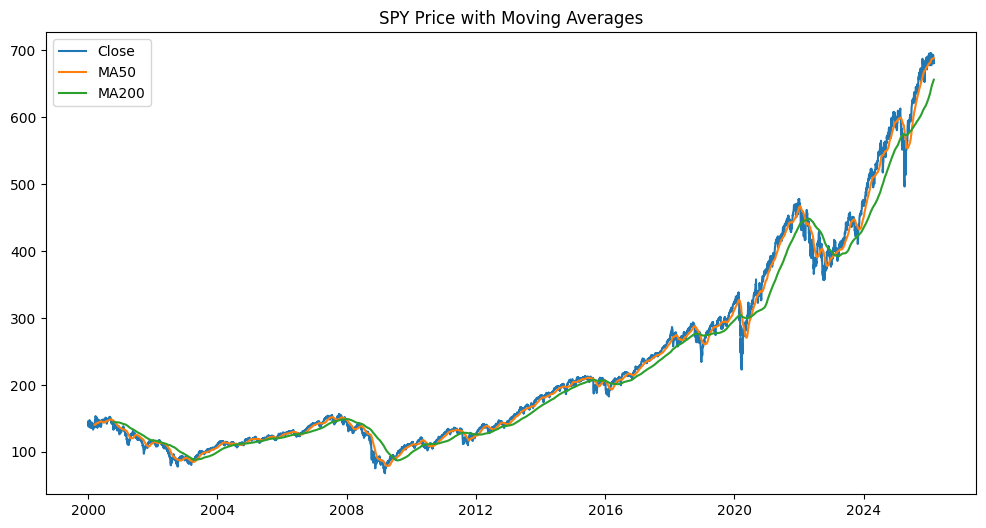

In [6]:
plt.figure(figsize=(12,6))
plt.plot(dSPY["Close"], label="Close")
plt.plot(dSPY["MA50"], label="MA50")
plt.plot(dSPY["MA200"], label="MA200")
plt.title("SPY Price with Moving Averages")
plt.legend()
plt.show()

## 5. Trading Signal

The strategy is long the market when the 50-day moving average is above the 200-day moving average.

Otherwise, it stays out of the market.

In [7]:
dSPY["signal"] = (dSPY["MA50"] > dSPY["MA200"]).astype(int)
dSPY[["MA50", "MA200", "signal"]].tail()

Price,MA50,MA200,signal
Date,,,
2026-02-27,687.782596,654.182700,1
2026-03-02,687.932797,654.680399,1
2026-03-03,688.111396,655.144099,1
2026-03-04,688.284597,655.617449,1
2026-03-05,688.298997,656.052999,1


## 6. Strategy Backtest

We compare:
- market returns
- strategy returns

In [8]:
dSPY["returns"] = dSPY["Close"].pct_change()
dSPY["strategy_returns"] = dSPY["signal"].shift(1) * dSPY["returns"]

dSPY[["returns", "strategy_returns"]].head()


##esto no me queda  muy claroopoooawdsomvfa+perwmgvañklremngvakñl

Price,returns,strategy_returns
Date,,
2000-01-03,NaN,NaN
2000-01-04,-0.039106,-0.0
2000-01-05,0.001789,0.0
2000-01-06,-0.016071,-0.0
2000-01-07,0.058076,0.0


In [9]:
dSPY[["returns", "strategy_returns"]] = dSPY[["returns", "strategy_returns"]].fillna(0)

dSPY["cum_market"] = (1 + dSPY["returns"]).cumprod()
dSPY["cum_strategy"] = (1 + dSPY["strategy_returns"]).cumprod()

dSPY[["cum_market", "cum_strategy"]].tail()

Price,cum_market,cum_strategy
Date,,
2026-02-27,4.716734,5.161570
2026-03-02,4.719416,5.164505
2026-03-03,4.677817,5.118983
2026-03-04,4.710821,5.155099
2026-03-05,4.684555,5.126357


## 7. Strategy Performance

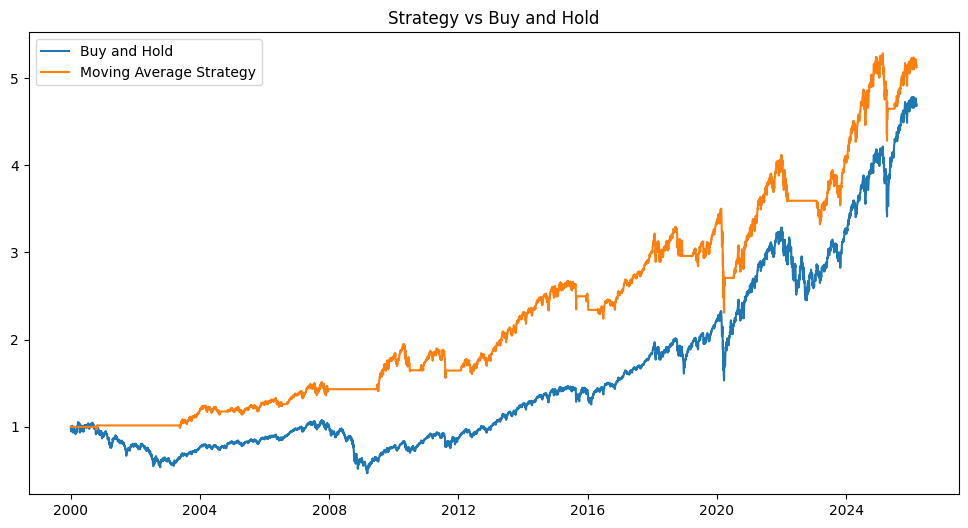

In [10]:
plt.figure(figsize=(12,6))
plt.plot(dSPY["cum_market"], label="Buy and Hold")
plt.plot(dSPY["cum_strategy"], label="Moving Average Strategy")
plt.title("Strategy vs Buy and Hold")
plt.legend()
plt.show()

## 8. Risk-Adjusted Performance

In [11]:
sharpe = np.sqrt(252) * dSPY["strategy_returns"].mean() / dSPY["strategy_returns"].std()
print("Sharpe Ratio:", round(sharpe, 3))

Sharpe Ratio: 0.561


In [12]:
drawdown = dSPY["cum_strategy"] / dSPY["cum_strategy"].cummax() - 1
max_drawdown = drawdown.min()

print("Max Drawdown:", round(max_drawdown, 3))

Max Drawdown: -0.341


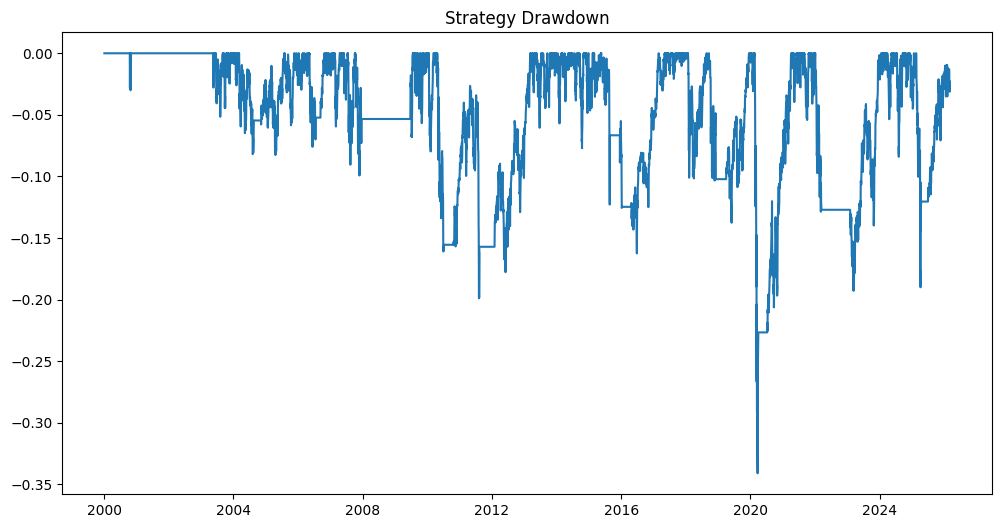

In [13]:
plt.figure(figsize=(12,6))
plt.plot(drawdown)
plt.title("Strategy Drawdown")
plt.show()

## 9. Conclusion

This notebook implemented a simple moving average crossover strategy on SPY.

Main takeaways:
- the strategy is easy to implement
- it may reduce drawdowns compared to buy-and-hold
- it can underperform during sideways markets
- this is a simple example and does not include transaction costs, slippage, or position sizing